<div align="center">

# Prédiction de la souscription d'un dépôt à terme  

## Sélection du modèle

<img src="https://raw.githubusercontent.com/komiadok/termdepositforecast/main/cover_image.jpg" width="500"/>

</div>

<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
📚 Chargement des librairies
</div>

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer, LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve

<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
🗃️ Partie 1 : Importation des données
</div>

In [2]:
# Chargement du dataset
data = pd.read_csv('../data/raw/bank-additional-full.csv', sep = ';')
print(f'Taille du dataframe : {data.shape}')

# Aperçu du dataset
data.head()

Taille du dataframe : (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Définition du chemin où se trouve utils
import sys
sys.path.append('../pipelines/')  

# Importation de la classe
from preprocess import DataCleaningPipeline

In [4]:
# Instanciation du pipeline
pipeline = DataCleaningPipeline(
    min_age=18,
    max_duration=300,
    max_calls=5,
    output_dir='../data/outputs'
)

# Transformation du DataFrame
cleaned_data = pipeline.fit_transform(data)
print(f'Taille du dataframe : {cleaned_data.shape}')

# Vérification des premières lignes
cleaned_data.head()

Taille du dataframe : (41183, 31)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,missing_job,missing_marital,missing_education,missing_default,missing_housing,missing_loan,outlier_duration,outlier_campaign,outlier_previous,never_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,False,False,False,False,False,False,False,False,False,True
1,57,services,married,high.school,missing,no,no,telephone,may,mon,...,False,False,False,True,False,False,False,False,False,True
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,False,False,False,False,False,False,False,False,False,True
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,False,False,False,False,False,False,False,False,False,True
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,False,False,False,False,False,False,True,False,False,True


<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
🛠️ Partie 2 : Prétraitement des données
</div>

### 1️⃣ Définition des features

In [5]:
# Variables numériques à standardiser
numerical_features = ['age', 'campaign', 'pdays', 'previous', 'euribor3m', 'cons.price.idx', 'cons.conf.idx']

# Variables catégorielles à encoder
onehot_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome'] # catégorielles sans ordre
ordinal_features = ['education'] # catégorielles avec ordre

# Variables temporelles à encoder
cyclic_features = ['month', 'day_of_week'] # sin/cos encoding

# Variables indicatrices
indicator_features = [col for col in cleaned_data.columns if col.startswith('missing') or col.startswith('outlier')]

# Ajout de la variable never_contacted
if 'never_contacted' in cleaned_data.columns:
    indicator_features.append('never_contacted')

# Suppression de la variable "outlier_duration" 
if 'outlier_duration' in indicator_features:
    indicator_features.remove('outlier_duration')

### 2️⃣ Conversion des variables temporelles

In [6]:
# Copie du dataframe
df = cleaned_data.copy()

# Mapping Mois lettres → nombres
mois_mapping = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,
    "may": 5, "jun": 6, "jul": 7, "aug": 8,
    "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

# Application du mapping
df['month'] = df['month'].map(mois_mapping)

# Mapping jour lettres -> nombres
jour_mapping = {
    "mon": 1, "tue": 2, "wed": 3, "thu": 4, "fri": 5
}

# Application du mapping
df['day_of_week'] = df['day_of_week'].map(jour_mapping)

### 3️⃣ Split des données

In [7]:
# Séparation features / target
X = df[numerical_features + onehot_features + ordinal_features + cyclic_features + indicator_features]
y_raw = df['y']

# Encodage binaire de la target
lb = LabelBinarizer()
y = lb.fit_transform(y_raw).ravel()

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 4️⃣ Préprocessing complet

In [8]:
# Définition du chemin où se trouve utils
import sys
sys.path.append('../')  

# Importation des fonctions à utiliser
from utils import CyclicEncoder, find_threshold_with_recall_priority

In [9]:
# Définition de l'ordre pour l'encodage ordinal de 'education'
education_order = ['missing', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 
                   'high.school', 'professional.course', 'university.degree']

# Encodage sin/cos de 'month' et 'day_of_week'
sin_cos_transformer = CyclicEncoder(max_vals=[12, 5], feature_names=cyclic_features)

In [10]:
# Définition du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_features),
        ('ordinal', OrdinalEncoder(categories=[education_order]), ordinal_features),
        ('cyclic', sin_cos_transformer, cyclic_features),  
        ('ind', 'passthrough', indicator_features)
    ]
)

<div style="background-color:#008080; color:white; padding:15px; border-radius:8px; font-weight:bold; font-size:16px;">
☑️ Partie 3 : Choix du modèle
</div>

### 5️⃣ Pipeline avec LogisticRegression Lasso

In [11]:
# Définition du pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000))
])

### 6️⃣ Recherche des hyperparamètres optimaux avec GridSearch

In [12]:
# Définition de la grille d'hyperparamètres à tester
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

# Mise en place d'une recherche par validation croisée (GridSearchCV)
grid_search = GridSearchCV(
    pipeline,            # pipeline qui inclut preprocessing + modèle
    param_grid,          # grille d'hyperparamètres à explorer
    cv=5,                # validation croisée en 5 plis
    scoring='roc_auc',   # métrique d'évaluation = ROC-AUC (pertinent en dataset déséquilibré)
    n_jobs=-1,           # utilise tous les cœurs CPU disponibles pour paralléliser
    verbose=2            # niveau de log (2 = affiche l’avancement détaillé)
)

### 7️⃣ Entraînement du modèle

In [13]:
# Début du chronomètre
start_time = time.time()

# Entraînement de chaque combinaison d’hyperparamètres de la grille sur les plis de validation croisée
grid_search.fit(X_train, y_train)

# Fin du chronomètre
end_time = time.time()

# Durée en secondes
execution_time = end_time - start_time
print(f"Durée d'exécution : {execution_time:.2f} secondes")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Durée d'exécution : 64.08 secondes


In [14]:
# Extraire nombre de coefficients non nuls pour chaque C
nonzero_coefs = []
for C in param_grid['classifier__C']:
    pipeline.set_params(classifier__C=C)
    pipeline.fit(X_train, y_train)
    n_nonzero = np.sum(pipeline.named_steps['classifier'].coef_ != 0)
    nonzero_coefs.append(n_nonzero)

# Enregistrement des résultats dans un DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['nonzero_coef'] = nonzero_coefs
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
print(cv_results_sorted[['param_classifier__C', 'mean_test_score', 'nonzero_coef']])

# Sélection du meillleur hyperparamètre
print("Meilleur hyperparamètre C :", grid_search.best_params_['classifier__C'])

   param_classifier__C  mean_test_score  nonzero_coef
1                 0.10         0.777872            36
2                 1.00         0.777524            40
3                10.00         0.777501            44
0                 0.01         0.775840            19
Meilleur hyperparamètre C : 0.1


In [15]:
# Prédiction avec le meilleur hyperparamètre
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1] # proba positives

### 8️⃣ Évaluation du modèle

#### La courbe de ROC

Dans le cadre de l’évaluation d’un modèle de classification binaire, il est essentiel d’aller au-delà de la simple mesure de précision (accuracy), particulièrement lorsque les classes sont déséquilibrées. La courbe **ROC (Receiver Operating Characteristic)** constitue un outil robuste et largement utilisé pour analyser la performance d’un modèle prédictif.<br> La courbe ROC représente la relation entre :
* le **Taux de vrais positifs (True Positive Rate – TPR ou Recall)** : proportion des observations positives correctement identifiées par le modèle,
* le **Taux de faux positifs (False Positive Rate – FPR)** : proportion des observations négatives incorrectement classées comme positives.

En faisant varier le seuil de décision du modèle, on obtient différents couples (TPR, FPR), qui permettent de tracer la courbe ROC. Plus la courbe est proche du coin supérieur gauche, meilleure est la capacité discriminante du modèle.<br> Un indicateur clé associé à cette courbe est l’**AUC (Area Under the Curve)**, qui mesure la surface sous la courbe ROC. Sa valeur varie entre **0,5** (performance aléatoire) et **1,0** (modèle parfait). L’AUC est particulièrement utile dans un contexte de déséquilibre des classes, car elle évalue la capacité du modèle à séparer correctement les classes, indépendamment d’un seuil spécifique.

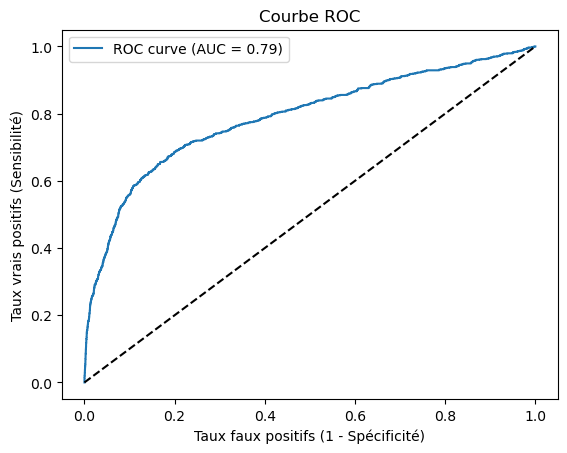

In [16]:
# --- 1. ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Taux faux positifs (1 - Spécificité)")
plt.ylabel("Taux vrais positifs (Sensibilité)")
plt.legend()
plt.title("Courbe ROC")
plt.show()

**Interprétation**

La courbe présentée montre une **performance correcte du modèle de régression logistique**. Avec une **AUC de 0,79**, le modèle atteint un niveau de discrimination satisfaisant, traduisant une capacité notable à distinguer les clients susceptibles de souscrire au dépôt à terme de ceux qui ne le feront pas.<br> La courbe se situe au-dessus de la diagonale de référence (hasard), ce qui indique que le modèle prend des décisions significativement plus pertinentes qu’un choix aléatoire.
* **Au début (près de 0,0)** : quand le seuil est très strict (proba ≈ 0.9), le modèle fait très peu de faux positifs (FPR proche de 0), mais il détecte aussi peu de positifs (TPR faible).
* **Au milieu (~0.2–0.4 FPR, 0.6–0.8 TPR)** : compromis intéressant → le modèle détecte 60–80 % des vrais positifs tout en gardant seulement 20–40 % de faux positifs.
* **Vers la droite (proche de 1,0)** : quand le seuil est très bas (proba ≈ 0.1), le modèle attrape presque tous les vrais positifs (TPR ≈ 1), mais il classe aussi beaucoup de négatifs en positifs (FPR ≈ 1)

En pratique, le modèle est suffisamment performant pour **prioriser les clients à cibler**. Le choix du seuil dépend de la **stratégie marketing** :
* Si l'objectif est de **maximiser les souscriptions**, il serait préférable de choisir un **seuil bas** (ex. 0,3) pour capter presque tous les clients qui vont souscrire (**haut TPR**). Dans ce cas, beaucoup de clients seront contactés inutilement car il y aura beaucoup de faux positifs (**haut FPR**) → coût de campagne élevé. 
* Si l'objectif est d'**optimiser les coûts**, il faudra faire une campagne ciblée donc choisir un **seuil haut** (ex. 0,7). Cela implique de ne contacter que les clients dont le modèle est très confiant. Les clients avec un **bas FPR** ne seront pas contactés, mais on pourrait passer à côté de nombreux clients qui auraient souscrit. 

#### La courbe précision-rappel

La **courbe précision–rappel (PR curve)** est un outil d’évaluation essentiel dans les problèmes de classification binaire, en particulier lorsque les classes sont **fortement déséquilibrées** (par exemple : détection de fraude, churn client, souscription à un produit rare). Elle est souvent préférée à la courbe de ROC. 
* **Précision (Precision)** : proportion de prédictions positives correctes parmi toutes les prédictions positives. Elle répond à la question : *“Parmi les clients prédits comme souscripteurs, combien le sont réellement ?”*
* **Rappel (Recall ou Sensibilité)** : proportion de vrais positifs correctement identifiés parmi toutes les observations positives réelles. Elle répond à la question : *“Parmi tous les vrais souscripteurs, combien avons-nous réussi à détecter ?”*

La courbe précision–rappel trace la précision en fonction du rappel pour différents seuils de probabilité. Contrairement à la courbe ROC, elle met davantage en évidence les performances sur la **classe minoritaire**, ce qui en fait un choix privilégié dans les contextes où la détection correcte des cas rares est critique.<br> Un indicateur synthétique associé est l’**AUPRC (Area Under the Precision–Recall Curve)** : plus il est élevé, meilleure est la capacité du modèle à trouver un équilibre entre précision et rappel.

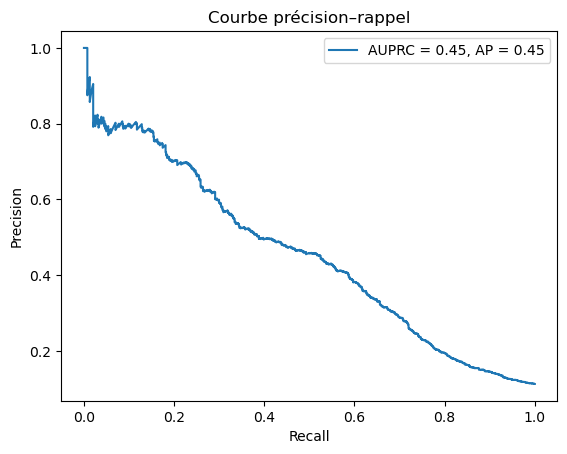

In [17]:
# --- 2. PR curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = auc(recall, precision)
ap = average_precision_score(y_test, y_proba)
plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {auprc:.2f}, AP = {ap:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe précision–rappel")
plt.legend()
plt.show()

**Interprétation**

La courbe précision-rappel indique une **aire sous la courbe (AUPRC) de 0,45**, ce qui traduit une performance correcte mais modérée. Cette valeur plus faible que celle observée avec la courbe ROC (AUC = 0,89) reflète l'impact du **déséquilibre de classes** : la courbe précision-rappel met en évidence la difficulté du modèle à maintenir une précision élevée tout en maximisant le rappel sur la classe minoritaire.<br> On observe que le modèle parvient à conserver une précision relativement bonne pour des niveaux de rappel faibles, mais que celle-ci diminue progressivement à mesure que le rappel augmente. 
* Lorsque **Recall augmente**, on identifie plus de cas positifs, mais **Precision diminue** car on accepte plus de faux positifs.
* À l’inverse, lorsque **Precision est élevée**, c'est souvent au détriment du rappel (on identifie moins de vrais positifs mais on est sûr de nos prédictions).

Cela signifie que le modèle identifie correctement les clients susceptibles de souscrire, mais avec **compromis** : 
* Si on met le seuil trop haut → très précis mais on rate beaucoup de clients.
* Si on met le seuil trop bas → on contacte beaucoup de clients non intéressés.

Le modèle peut encore être amélioré en ajoutant des variables, en ajustant les hyperparamètres ou en équilibrant la classe cible.

#### 9️⃣ Choix du seuil optimal

Dans notre contexte : 
* Appeler un client qui ne souscrit pas (FP : Faux Positif) → coût de l’appel, possible irritabilité du client.
* Ne pas appeler un client qui aurait souscrit (FN: Faux Négatif) → perte de revenu potentiel.

Le coût du FP est tangible (argent et ressources), mais le coût du FN correspond au **manqué de souscription**, donc plus critique pour le ROI. On va chercher un compromis.

La courbe précision-rappel indique un **Average Precision (AP) = 0,45**, ce qui est correct mais pas exceptionnel. 
* La **précision** correspond à *"parmi les clients qu'on appelle, combien vont vraiment souscrire"*.
* Le **rappel** correspond à *"parmi tous les clients qui pourraient souscrire, combien allons-nous contacter"*.

Dans une campagne téléphonique ciblée, l'objectif est de **maximiser la précision**, quitte à perdre un peu de rappel : moins d'appels inutiles → ROI meilleur. Il convient donc de parcourir la courbe PR et de choisir le **seuil qui donne une précision suffisamment élevée**, par exemple 0,6 ou 0,7, selon ce qui est acceptable pour le coût d'un appel. Il faut vérifier le rappel correspondant pour s'assurer que trop de clients potentiels ne sont pas manqués.

In [18]:
# Recherche du seuil optimal
best = find_threshold_with_recall_priority(y_test, y_proba, min_precision=0.35)
print(f"Seuil choisi : {best['threshold']:.3f}")
print(f"Précision : {best['precision']:.3f}, Rappel : {best['recall']:.3f}")

Seuil choisi : 0.565
Précision : 0.350, Rappel : 0.627


In [19]:
# Application du seuil optimal
seuil_optimal = 0.565
y_pred = (y_proba >= seuil_optimal).astype(int)

#### La matrice de confusion

La matrice de confusion est un outil fondamental pour évaluer la performance d’un modèle de classification. Elle compare les prédictions du modèle aux valeurs réelles et permet d’identifier non seulement la performance globale, mais aussi la nature des erreurs commises.<br> Elle se présente sous la forme d’un tableau croisé :
|                | Prédit : Positif  | Prédit : Négatif  |
|----------------|-------------------|-------------------|
| Réel : Positif | Vrai Positif (TP) | Faux Négatif (FN) |
| Réel : Négatif | Faux Positif (FP) | Vrai Négatif (TN) |

* **TP (True Positive)** : cas positifs correctement identifiés.
* **TN (True Negative)** : cas négatifs correctement identifiés.
* **FP (False Positive)** : cas négatifs prédits à tort comme positifs (ex. client identifié comme souscripteur alors qu'il ne le sera pas).
* **FN (False Negative)** : cas positifs prédits à tort comme négatifs (ex. client réellement souscripteur mais que le modèle n'a pas détecté).

À partir de cette matrice, on calcule les métriques clés :
* **Accuracy** : proportion totale de bonnes prédictions
* **Précision** : fiabilité des prédictions positives
* **Recall (Sensibilité)** : capacité à détecter tous les positifs
* **F1-score** : compromis entre précision et rappel

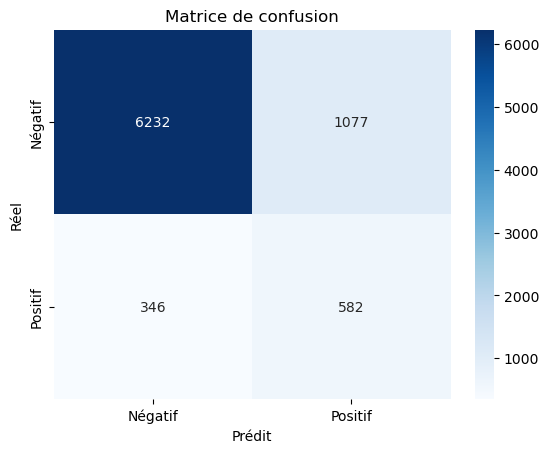

In [20]:
# --- 3. Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Négatif", "Positif"], yticklabels=["Négatif", "Positif"])
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.title("Matrice de confusion")
plt.show()

**Interprétation**

La matrice de confusion met en évidence les forces et les limites du modèle sur ce jeu de données. On observe que le modèle prédit correctement **6232 vrais négatifs** et **582 vrais positifs**, ce qui montre une bonne capacité à reconnaître la majorité des clients qui ne souscrivent pas, ainsi qu'une partie significative de ceux qui acceptent effectivement le dépôt à terme.<br> Cependant, le modèle génère également **1077 faux positifs** et **346 faux négatifs**, révélant des erreurs notables de classification. 
* Les **faux positifs** correspondent à des clients contactés à tort (le modèle les considère comme intéressés alors qu'ils ne le sont pas), ce qui représente un coût inutile en termes de ressources et d'appels.
* Les **faux négatifs** correspondent à des **clients réellement intéressés** qui n'ont pas été identifiés par le modèle, entraînant une perte d'opportunités commerciales.

Cette répartition indique que le modèle tend à privilégier la détection des clients susceptibles de souscrire (rappel relativement correct), mais qu’il accepte un volume non négligeable de faux positifs, ce qui réduit la précision.<br> En pratique, ces résultats suggèrent que le modèle peut être utile pour orienter une campagne téléphonique ciblée, en identifiant un noyau de clients à fort potentiel, mais qu’il faudra rester attentif aux faux positifs qui alourdissent les coûts. Des ajustements du seuil de décision, ou l’utilisation de techniques de rééchantillonnage ou de pondération des classes, pourraient améliorer l’équilibre entre précision et rappel, selon la stratégie prioritaire (réduction des coûts ou maximisation des souscriptions).

In [21]:
# --- 4. Rapport global ---
print(classification_report(y_test, y_pred, digits=3))
print("Log-Loss:", log_loss(y_test, y_proba))
print("Brier Score:", brier_score_loss(y_test, y_proba))

              precision    recall  f1-score   support

           0      0.947     0.853     0.898      7309
           1      0.351     0.627     0.450       928

    accuracy                          0.827      8237
   macro avg      0.649     0.740     0.674      8237
weighted avg      0.880     0.827     0.847      8237

Log-Loss: 0.5315958555754846
Brier Score: 0.17046302061053045


L’évaluation du modèle met en évidence une bonne capacité de détection de la classe majoritaire (clients qui ne souscrivent pas à un dépôt à terme). En effet, la précision atteint **94,7%** et le rappel **85,3%** pour cette catégorie, ce qui traduit une excellente aptitude à identifier correctement les non-souscripteurs. Cette performance contribue à limiter les risques d’erreurs liées à une mauvaise exclusion de clients non intéressés.

En revanche, la performance est plus mitigée pour la classe minoritaire (clients qui souscrivent). Le modèle parvient à identifier **62,7%** des véritables souscripteurs (rappel), mais avec une précision limitée à **35,1%**, ce qui signifie que près de deux tiers des clients prédits comme intéressés ne le sont pas réellement.Cette faiblesse entraîne un volume important de faux positifs, susceptibles de générer des coûts supplémentaires dans le cadre d’une campagne téléphonique. Le **score F1 de 0,45** illustre cet équilibre imparfait entre rappel et précision.

Sur le plan global, l’**accuracy de 82,7%** est correcte mais reflète surtout l’importance de la classe dominante. Les indicateurs de calibration (Log-Loss = 0,53 et Brier Score = 0,17) suggèrent que les probabilités prédites par le modèle sont relativement fiables, bien qu’elles puissent encore être améliorées. Ces résultats indiquent que le modèle constitue une base solide pour un ciblage marketing, mais qu’il nécessite des ajustements pour être véritablement exploitable dans un contexte opérationnel.

En pratique, le modèle peut déjà servir à **prioriser les appels vers les clients présentant la probabilité la plus élevée de souscription**, mais une vigilance particulière doit être apportée aux faux positifs. Pour améliorer le retour sur investissement des campagnes, deux pistes peuvent être envisagées : d’une part, **ajuster le seuil de décision** afin de privilégier une meilleure précision, et d’autre part, **explorer une approche de top-N scoring**, consistant à contacter uniquement un pourcentage restreint des clients les mieux classés. Ces ajustements permettraient d’optimiser le compromis entre précision et rappel en fonction des priorités stratégiques de l’entreprise.

#### 🔟 TOP 15 Coefficients de Régression Logistique L1

Les coefficients L1 permettent d’identifier quelles caractéristiques clients (revenu, profession, ancienneté, montant du compte…) influencent le plus la souscription. Les variables avec coefficient nul peuvent être ignorées pour simplifier les modèles ou les campagnes marketing ciblées.

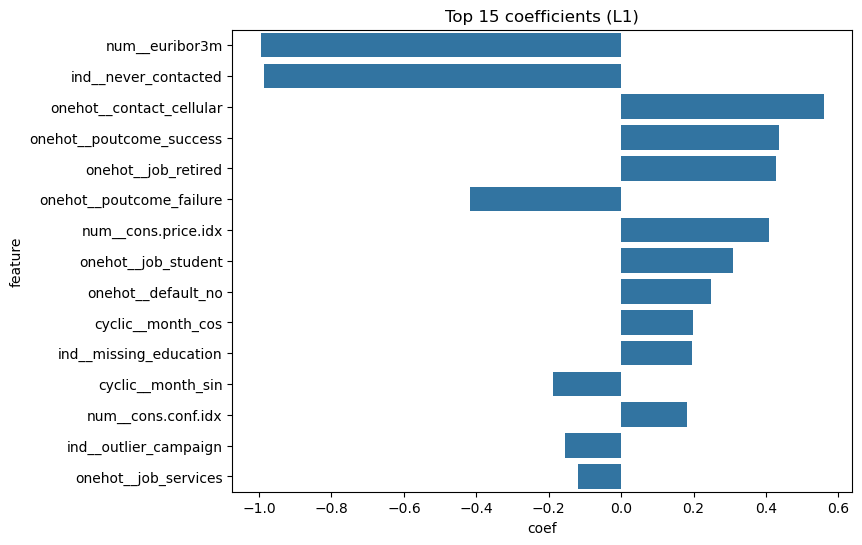

In [22]:
# --- 5. Coefficients L1 ---
model = best_pipeline
coefs = model.named_steps["classifier"].coef_.ravel()
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df = coef_df.sort_values(by="coef", key=abs, ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="coef", y="feature", data=coef_df.head(15))
plt.title("Top 15 coefficients (L1)")
plt.show()

**Interprétation**

Le graphique des coefficients L1 met en évidence les **15 variables les plus influentes** du modèle de régression logistique. L’axe horizontal représente la valeur du coefficient, tandis que l’axe vertical liste les caractéristiques (features). Les coefficients positifs indiquent une **augmentation de la probabilité** de souscrire à un dépôt à terme, tandis que les coefficients négatifs correspondent à une **diminution de cette probabilité**. 

Parmi les variables, `num__euribor3m` se distingue comme la plus influente avec un coefficient d’environ **-1,0**, indiquant qu’une hausse de cette variable diminue fortement la probabilité de souscription au dépôt à terme. Elle est suivie de `ind__never_contacted` avec un coefficient proche de **-1,0**, confirmant que les clients n’ayant jamais été contactés ont une probabilité beaucoup plus faible de souscrire. 

À l’inverse, `onehot__contact_cellular` présente un coefficient positif d'environ **0,55**, traduisant que le fait de contacter un client via un téléphone portable augmente significativement la probabilité de souscription. De même, `onehot__poutcome_success` (résultat positif d'une campagne précédente) et `onehot__job_retired` (clients retraités) affichent des coefficients d'environ **0,45**, ce qui suggère que ces profils sont plus enclins à souscrire. En revanche, `onehot__poutcome_failure`, avec un coefficient négatif proche de **-0,4*, réduit la probabilité de souscription.

Enfin, certaines variables comme `num__cons.price.idx` (indice des prix à la consommation) et `onehot__job_student` ont des coefficients légèrement positifs, tandis que d'autres comme `ind__outlier_campaign` et `onehot__job_services` ont une influence plus faible.

En pratique, cette analyse des coefficients permet de comprendre l'impact relatif des différentes caractéristiques sur la décision du modèle et de guider les actions stratégiques : 
* cibler les clients contactés par téléphone portable,
* donner la priorité à ceux ayant eu un succès dans les campagnes précédentes,
* être vigilant sur les périodes où le taux Euribor est élevé, car cela réduit fortement l'appétence des clients pour les dépôts à terme.